In [1]:
import glob
import matplotlib.pyplot as plt
import numpy as np
import os
from plot_progress import gather_metrics
from parse_levels import find_levels_in_configs, find_levels_in_configs_glob
from parse_levels import process_metrics, human_train_time_dict, convert_to_dict, compute_gap_in_percentage
from parse_levels import filter_folder_info
import pandas as pd
import matplotlib.ticker as ticker
from plot_utils import plot_gap_comparison
import re
import copy
import json

In [2]:
# for each item in the dict, if any two have the same 'record', remove the one with lower number of steps in metric
def deduplicate_metrics(search_results):
    records_length_so_far = {}
    new_search_results = {}
    for key, value in search_results.items():
        if value['record'] not in records_length_so_far:
            records_length_so_far[value['record']] = (len(value['metrics']['step']), key)
            new_search_results[key] = value
        else:
            if len(value['metrics']['step']) > records_length_so_far[value['record']][0]:
                new_search_results.pop(records_length_so_far[value['record']][1])

                records_length_so_far[value['record']] = (len(value['metrics']['step']), key)
                new_search_results[key] = value
    return new_search_results



In [4]:
# ori_results = find_levels_in_configs_glob(
#     [
#         '/checkpoint/maui/zhaobc/scientist/workspace/record_*',
#         # '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250424_*',
#         # '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250425_*',
#         # '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250405_*'
#         # '/checkpoint/maui/zhaobc/scientist/workspace/record_1[2-8]_20250412_*',
#         #  '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250408_*',
#         # '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250405_*'
#         # '/checkpoint/maui/zhaobc/scientist/workspace/record_1[2-8]_20250409_*',
#     ]
# )
with open('/home/zhaobc/scientist/plot/results.cache', 'r') as f:
    ori_results = json.load(f)

In [5]:
folder_info = ori_results

In [6]:
len(folder_info)

888

In [7]:
folder_info

{'record_2_20250427_164055_2116212-2116210-1': {'record': 2,
  'levels': [125],
  'ideator': 'dummy',
  'knowledge_coder': False,
  'runner': 'aide',
  'model': 'deepseek-r1',
  'n_initial_hypotheses': 3,
  'n_hypotheses': 1,
  'debug_prob': 0.5},
 'record_11_20250409_202152_1823337-1823335-0': {'record': 11,
  'levels': [1],
  'ideator': 'dummy',
  'knowledge_coder': False,
  'runner': 'bon',
  'model': 'o3-mini',
  'n_initial_hypotheses': None,
  'n_hypotheses': 3,
  'debug_prob': None},
 'record_15_20250414_104707_1975340-1975335-4': {'record': 15,
  'levels': [12],
  'ideator': 'dummy',
  'knowledge_coder': False,
  'runner': 'aide',
  'model': 'o3-mini',
  'n_initial_hypotheses': 3,
  'n_hypotheses': 3,
  'debug_prob': 0.5},
 'record_11_20250415_152538_1985074-1985074-10': {'record': 11,
  'levels': [12],
  'ideator': 'dummy',
  'knowledge_coder': False,
  'runner': 'bon',
  'model': 'o3-mini',
  'n_initial_hypotheses': None,
  'n_hypotheses': 50,
  'debug_prob': None},
 'record_1

In [8]:
# Filter the dictionary to only include entries with 'knowledge_coder': True
filtered_folder_info = {key: value for key, value in folder_info.items() if value['knowledge_coder']}
# Print the filtered dictionary
print(filtered_folder_info)

{'record_3_20250409_202041_1823291-1823288-2': {'record': 3, 'levels': [1], 'ideator': 'base', 'knowledge_coder': True, 'runner': 'aide', 'model': 'deepseek-r1', 'n_initial_hypotheses': 3, 'n_hypotheses': 1, 'debug_prob': 1.0}, 'record_9_20250409_202041_1823297-1823288-8': {'record': 9, 'levels': [1], 'ideator': 'base', 'knowledge_coder': True, 'runner': 'aide', 'model': 'deepseek-r1', 'n_initial_hypotheses': 3, 'n_hypotheses': 1, 'debug_prob': 1.0}, 'record_6_20250409_202041_1823294-1823288-5': {'record': 6, 'levels': [1], 'ideator': 'base', 'knowledge_coder': True, 'runner': 'aide', 'model': 'deepseek-r1', 'n_initial_hypotheses': 3, 'n_hypotheses': 1, 'debug_prob': 1.0}, 'record_4_20250409_202041_1823292-1823288-3': {'record': 4, 'levels': [1], 'ideator': 'base', 'knowledge_coder': True, 'runner': 'aide', 'model': 'deepseek-r1', 'n_initial_hypotheses': 3, 'n_hypotheses': 1, 'debug_prob': 1.0}, 'record_10_20250409_202041_1823298-1823288-9': {'record': 10, 'levels': [1], 'ideator': 'ba

In [9]:
len(filtered_folder_info)

11

In [10]:
# flat search -- n_initial_hypotheses = 50
flat_params = [
    ('runner', 'bon'),
    ('n_initial_hypotheses', 50),
]
# tree search -- n_initial_hypotheses = 1, n_hypotheses = 3
tree_params = [
    ('runner', 'bon'),
    ('n_initial_hypotheses', 1),
    ('n_hypotheses', 3),
]
# forest search -- n_initial_hypotheses = 3, n_hypotheses = 3
forest_params = [
    ('runner', 'bon'),
    ('n_initial_hypotheses', 3),
    ('n_hypotheses', 3),
]
# AIDE -- n_initial_hypotheses = 3, n_hypotheses = 1, debug_prob = 0.5
aide_params = [
    ('runner', 'aide'),
    ('n_initial_hypotheses', 3),
    ('n_hypotheses', 1),
    ('debug_prob', 0.5),
]
# MultiAIDE -- n_initial_hypotheses = 3, n_hypotheses = 3, debug_prob = 0.5
multi_aide_params = [
    ('runner', 'aide'),
    ('n_initial_hypotheses', 3),
    ('n_hypotheses', 3),
    ('debug_prob', 0.5),
]
# for each search algo, we get the R1 and O3 with level 1, 12, 125 results for plotting
# thats 6 results for each search algo, so we plot with 3 columns (level) and 2 rows (R1 and O3)

search_algo_params = {
    'flat': flat_params,
    'tree': tree_params,
    'forest': forest_params,
    'aide': aide_params,
    'multi_aide': multi_aide_params,
}

plot_info = {}

for search_algo, params in search_algo_params.items():
    plot_info[search_algo] = {}
    for level in [1, 12, 125]:
        plot_info[search_algo][level] = {}
        for model in ['deepseek-r1', 'o3-mini']:
            search_params = params + [('levels', level), ('model', model)]
            filtered_folder_info = filter_folder_info(folder_info, search_params)
            print(f'{search_algo} {level} {model} {len(filtered_folder_info)}')
            plot_info[search_algo][level][model] = filtered_folder_info



flat 1 deepseek-r1 18
flat 1 o3-mini 18
flat 12 deepseek-r1 18
flat 12 o3-mini 18
flat 125 deepseek-r1 18
flat 125 o3-mini 18
tree 1 deepseek-r1 18
tree 1 o3-mini 18
tree 12 deepseek-r1 18
tree 12 o3-mini 18
tree 125 deepseek-r1 18
tree 125 o3-mini 18
forest 1 deepseek-r1 18
forest 1 o3-mini 18
forest 12 deepseek-r1 18
forest 12 o3-mini 18
forest 125 deepseek-r1 36
forest 125 o3-mini 36
aide 1 deepseek-r1 18
aide 1 o3-mini 18
aide 12 deepseek-r1 46
aide 12 o3-mini 36
aide 125 deepseek-r1 46
aide 125 o3-mini 46
multi_aide 1 deepseek-r1 18
multi_aide 1 o3-mini 18
multi_aide 12 deepseek-r1 18
multi_aide 12 o3-mini 18
multi_aide 125 deepseek-r1 34
multi_aide 125 o3-mini 26


In [11]:
plot_info['flat'][1]['deepseek-r1']

{'record_16_20250416_093732_1992420-1992414-5': {'record': 16,
  'levels': [1],
  'ideator': 'dummy',
  'knowledge_coder': False,
  'runner': 'bon',
  'model': 'deepseek-r1',
  'n_initial_hypotheses': 50,
  'n_hypotheses': 50,
  'debug_prob': None},
 'record_8_20250416_094447_1992671-1992609-7': {'record': 8,
  'levels': [1],
  'ideator': 'dummy',
  'knowledge_coder': False,
  'runner': 'bon',
  'model': 'deepseek-r1',
  'n_initial_hypotheses': 50,
  'n_hypotheses': 50,
  'debug_prob': None},
 'record_15_20250416_093732_1992419-1992414-4': {'record': 15,
  'levels': [1],
  'ideator': 'dummy',
  'knowledge_coder': False,
  'runner': 'bon',
  'model': 'deepseek-r1',
  'n_initial_hypotheses': 50,
  'n_hypotheses': 50,
  'debug_prob': None},
 'record_10_20250416_094447_1992609-1992609-9': {'record': 10,
  'levels': [1],
  'ideator': 'dummy',
  'knowledge_coder': False,
  'runner': 'bon',
  'model': 'deepseek-r1',
  'n_initial_hypotheses': 50,
  'n_hypotheses': 50,
  'debug_prob': None},
 '

In [12]:
figure_data = {}
for search_algo in search_algo_params.keys():
    for level in [1, 12, 125]:
        for model in ('deepseek-r1', 'o3-mini'):
            plot_info[search_algo][level][model] = process_metrics(plot_info[search_algo][level][model])
            plot_info[search_algo][level][model] = deduplicate_metrics(plot_info[search_algo][level][model])
            figure_data[f'{search_algo}_{level}_{model}'] = convert_to_dict(plot_info[search_algo][level][model])


In [13]:
figure_data['flat_1_deepseek-r1']

{16: 228764.0,
 8: 662205.0,
 15: 236912.0,
 10: 477150.0,
 2: 1671485.0,
 12: 300426.0,
 9: 482448.0,
 5: 949528.0,
 3: 1282839.0,
 13: 288904.0,
 7: 722142.0,
 4: 1022446.0,
 6: 766259.0,
 11: 436324.0,
 18: 13945.0,
 17: 217202.0,
 1: 2201846.0,
 14: 273107.0}

In [14]:
for key in figure_data.keys():
    figure_data[key] = compute_gap_in_percentage(figure_data[key])
    figure_data[key] = {str(k): v for k, v in figure_data[key].items()}
    del figure_data[key]['6']

In [16]:
figure_data

{'flat_1_deepseek-r1': {'16': 0.33396840517583554,
  '8': 0.0,
  '15': 0.5359161563824776,
  '10': 0.0,
  '2': 0.6536231197930513,
  '12': 0.6211386173931654,
  '9': 0.8133258165674219,
  '5': 0.0,
  '3': 1.2239269254919616,
  '13': 0.05395855791112708,
  '7': 0.45937925622592835,
  '4': 0.7929712786617151,
  '11': 0.053225832227957744,
  '17': 0.3716897117412702,
  '1': 1.0106536993916315,
  '14': 0.0},
 'flat_1_o3-mini': {'15': 0.3857748469147433,
  '8': 0.0,
  '17': 0.388563393484884,
  '2': 0.6543174807806462,
  '12': 0.17856888064493115,
  '9': 1.1523202142278284,
  '5': 0.0,
  '7': 0.6808879107398955,
  '13': 0.018684872439813153,
  '1': 1.0053163014785964,
  '14': 0.0,
  '4': 0.037803936265658186,
  '16': 0.3496070492974518,
  '10': 0.8590955656373481,
  '11': 0.06942291403640548,
  '3': 1.2239269254919616},
 'flat_12_deepseek-r1': {'1': 0.0,
  '17': 0.3853995781579564,
  '3': 1.2239269254919616,
  '8': 0.0,
  '4': 0.01841220628485117,
  '10': 0.0,
  '11': 0.08931168395314273,
 

In [15]:
# replace the ones with 300% improvement with 0 as they might be summarizer mistakes
for key in figure_data.keys():
    for k, v in figure_data[key].items():
        if v > 3 or v < 0:
            print(f'found {v} in {key} {k}')
            figure_data[key][k] = 0.

found 3.8758738538702726 in flat_12_deepseek-r1 1
found 13.95647592565491 in forest_12_o3-mini 10
found 17.799760403086573 in aide_1_deepseek-r1 9
found 4.224868197658833 in aide_1_deepseek-r1 8
found 16.380951816792447 in aide_1_deepseek-r1 3
found -0.11502478213210096 in aide_1_deepseek-r1 2
found 16.421493478029074 in aide_12_o3-mini 3
found 16.421493478029074 in multi_aide_12_o3-mini 3


In [ ]:
plot_info['flat'][1]['deepseek-r1']['record_3_20250416_094447_1992666-1992609-2']

{'record': 3,
 'levels': [1],
 'ideator': 'dummy',
 'knowledge_coder': False,
 'runner': 'bon',
 'model': 'deepseek-r1',
 'n_initial_hypotheses': 50,
 'n_hypotheses': 50,
 'debug_prob': None,
 'metrics':     step   val_loss  train_time
 0      0   3.281300   1282839.0
 1      1        NaN         NaN
 2      2        NaN         NaN
 3      3        NaN         NaN
 4      4        NaN         NaN
 5      5        NaN         NaN
 6      6        NaN         NaN
 7      7        NaN         NaN
 8      8        NaN         NaN
 9      9        NaN         NaN
 10    10        NaN         NaN
 11    11        NaN         NaN
 12    12        NaN         NaN
 13    13        NaN         NaN
 14    14        NaN         NaN
 15    15        NaN         NaN
 16    16        NaN         NaN
 17    17        NaN         NaN
 18    18        NaN         NaN
 19    19        NaN         NaN
 20    20        NaN         NaN
 21    21  10.952500         NaN
 22    22        NaN         NaN
 23  

In [21]:
plot_info['flat'][1]['deepseek-r1']['record_4_20250416_094447_1992667-1992609-3']

{'record': 4,
 'levels': [1],
 'ideator': 'dummy',
 'knowledge_coder': False,
 'runner': 'bon',
 'model': 'deepseek-r1',
 'n_initial_hypotheses': 50,
 'n_hypotheses': 50,
 'debug_prob': None,
 'metrics':     step  val_loss  train_time
 0      0    3.2772   1301740.0
 1      1       NaN         NaN
 2      2       NaN         NaN
 3      3       NaN         NaN
 4      4       NaN         NaN
 5      5       NaN         NaN
 6      6       NaN         NaN
 7      7       NaN         NaN
 8      8       NaN         NaN
 9      9       NaN         NaN
 10    10       NaN         NaN
 11    11       NaN         NaN
 12    12       NaN         NaN
 13    13       NaN         NaN
 14    14       NaN         NaN
 15    15       NaN         NaN
 16    16       NaN         NaN
 17    17       NaN         NaN
 18    18       NaN         NaN
 19    19       NaN         NaN
 20    20       NaN         NaN
 21    21       NaN         NaN
 22    22       NaN         NaN
 23    23    3.2908         N

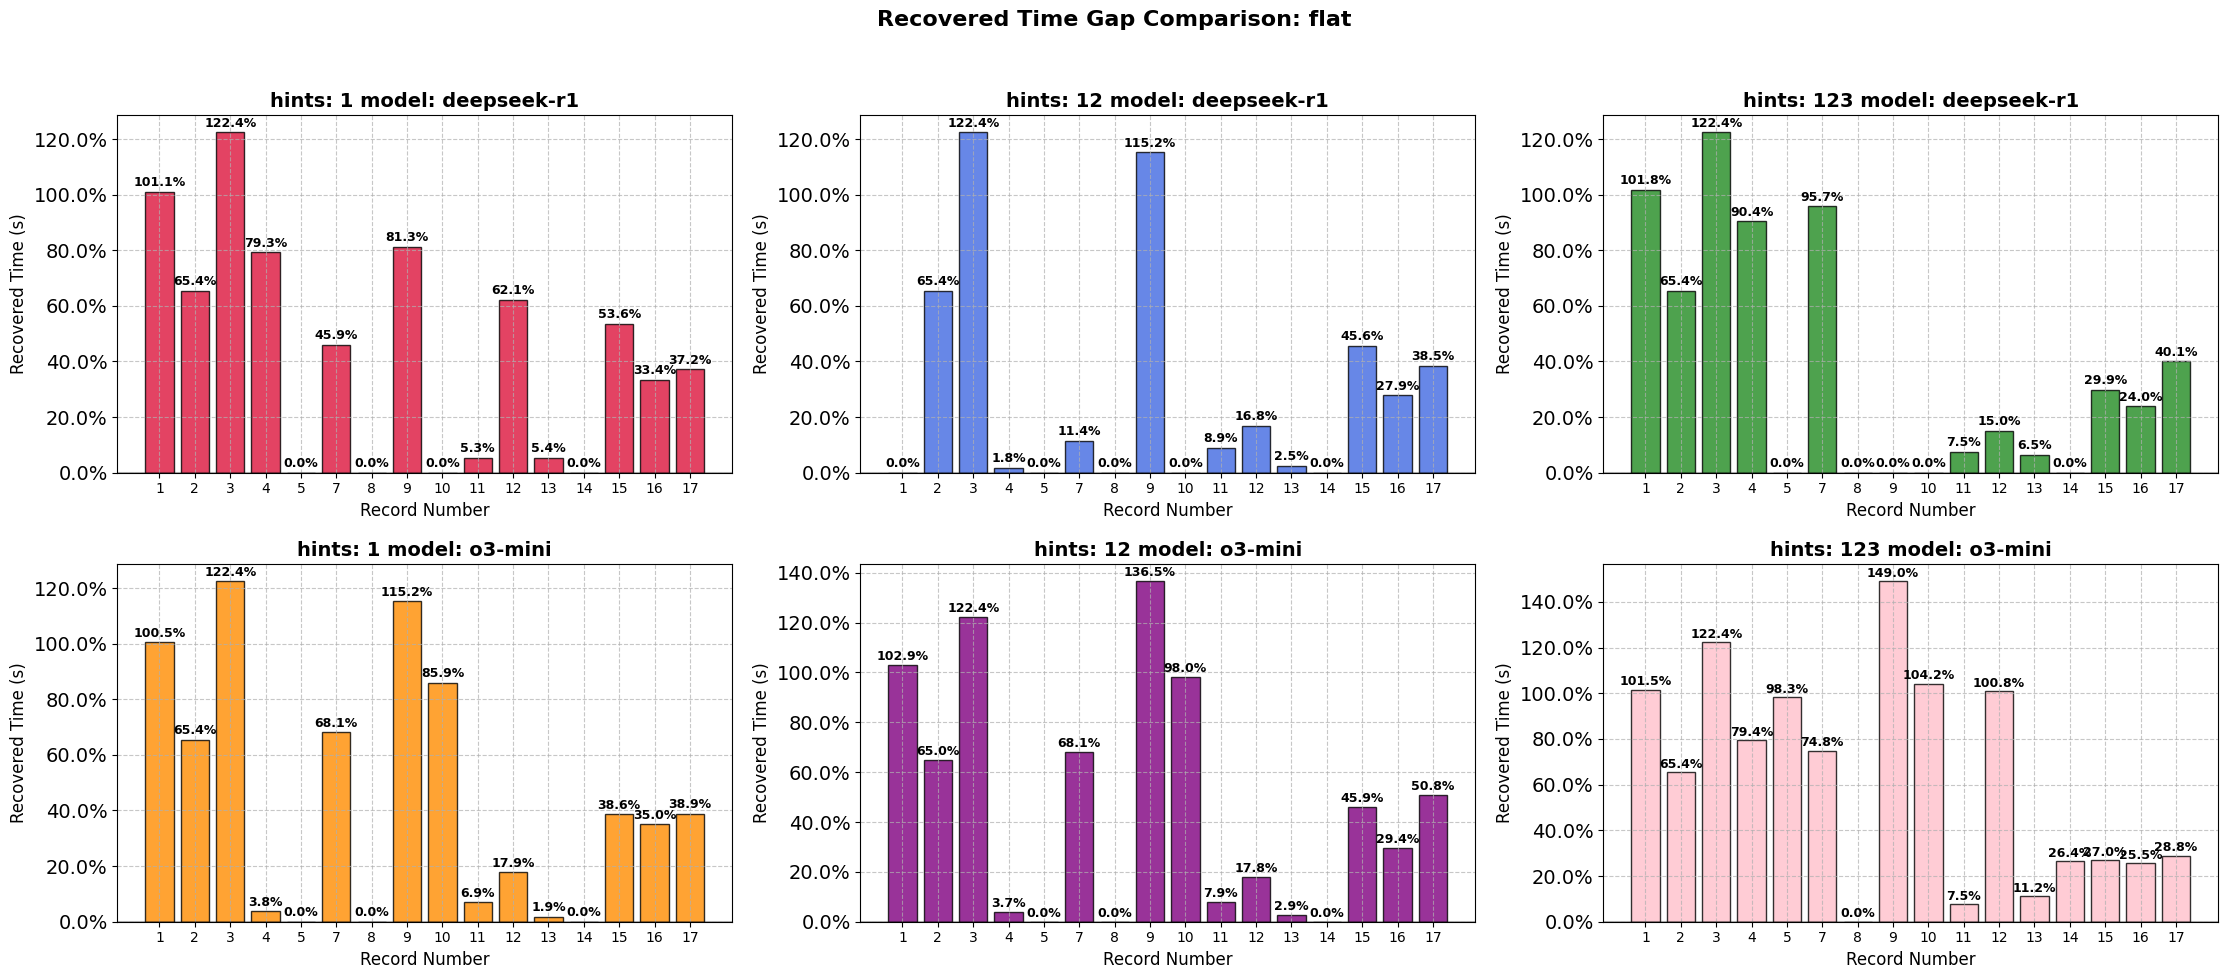

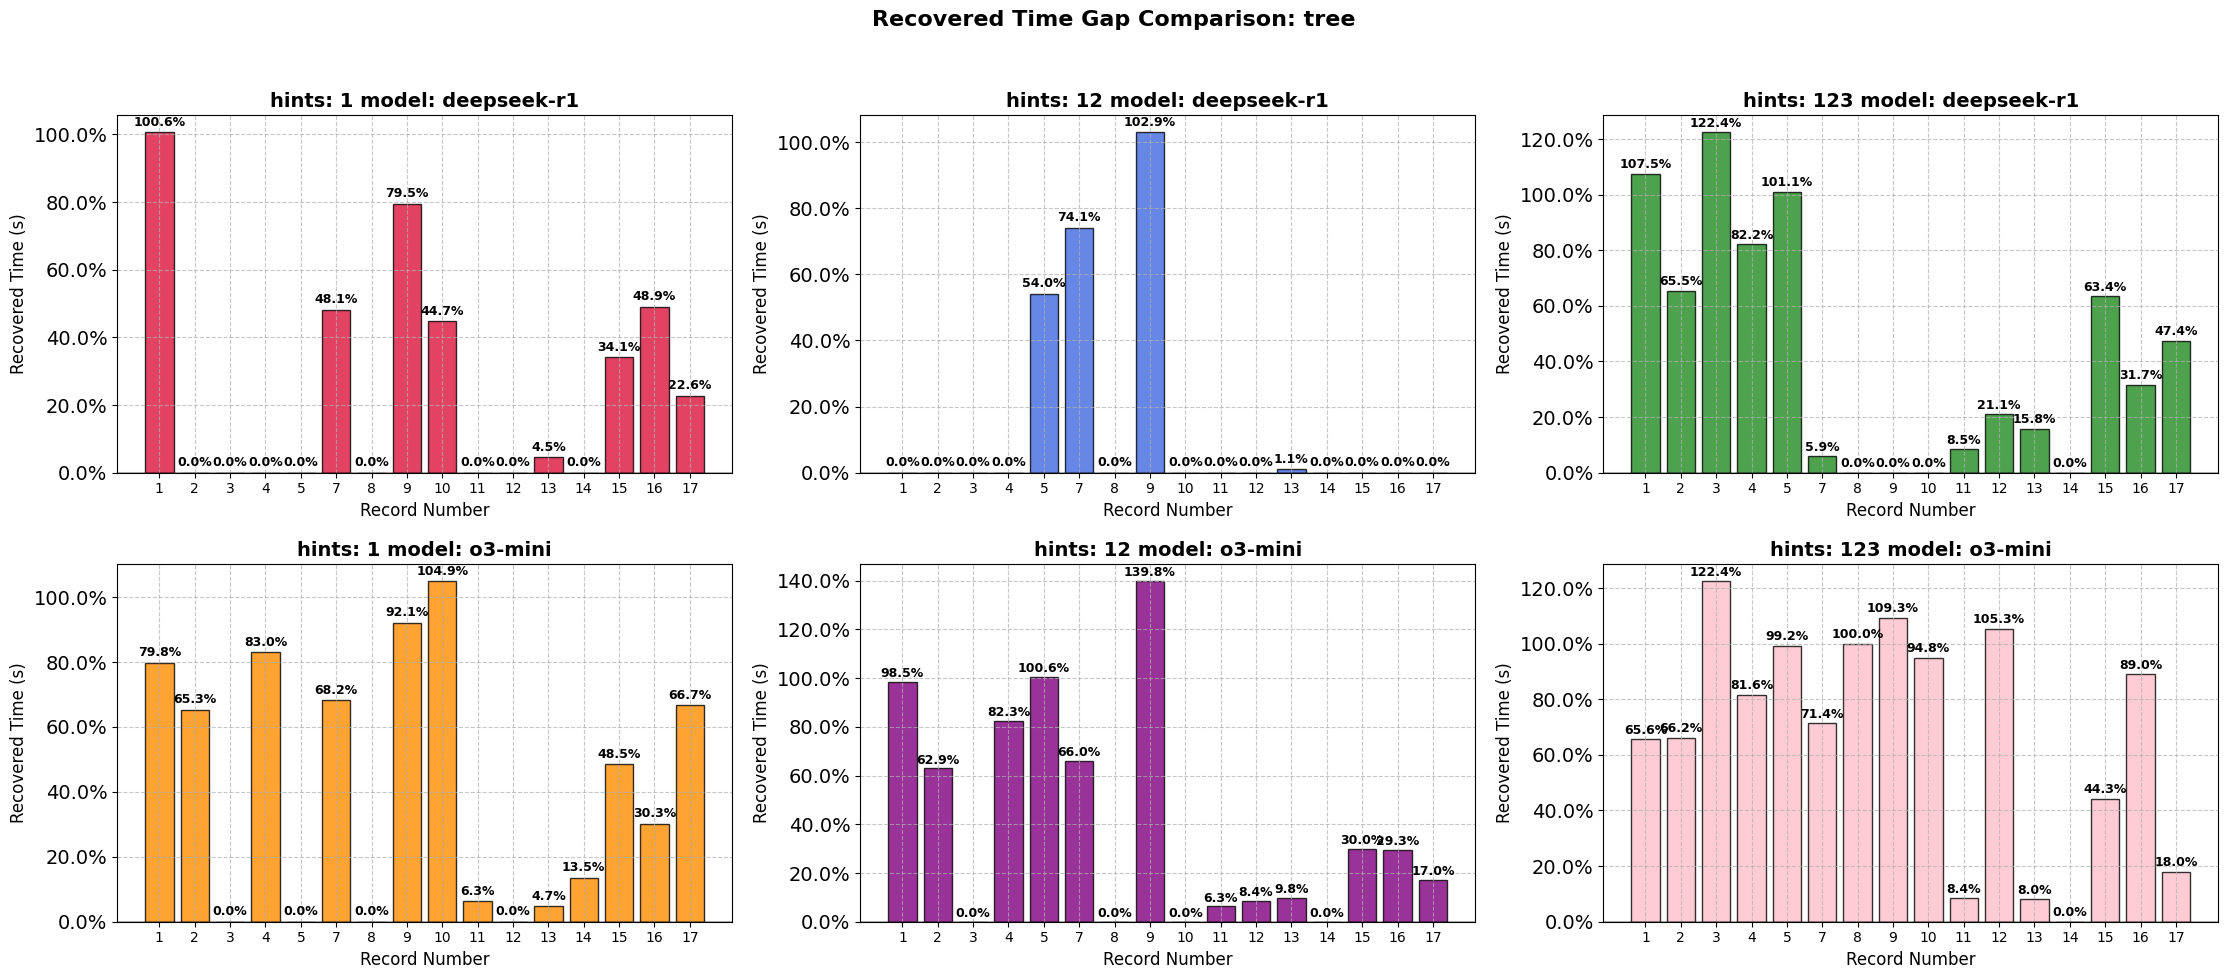

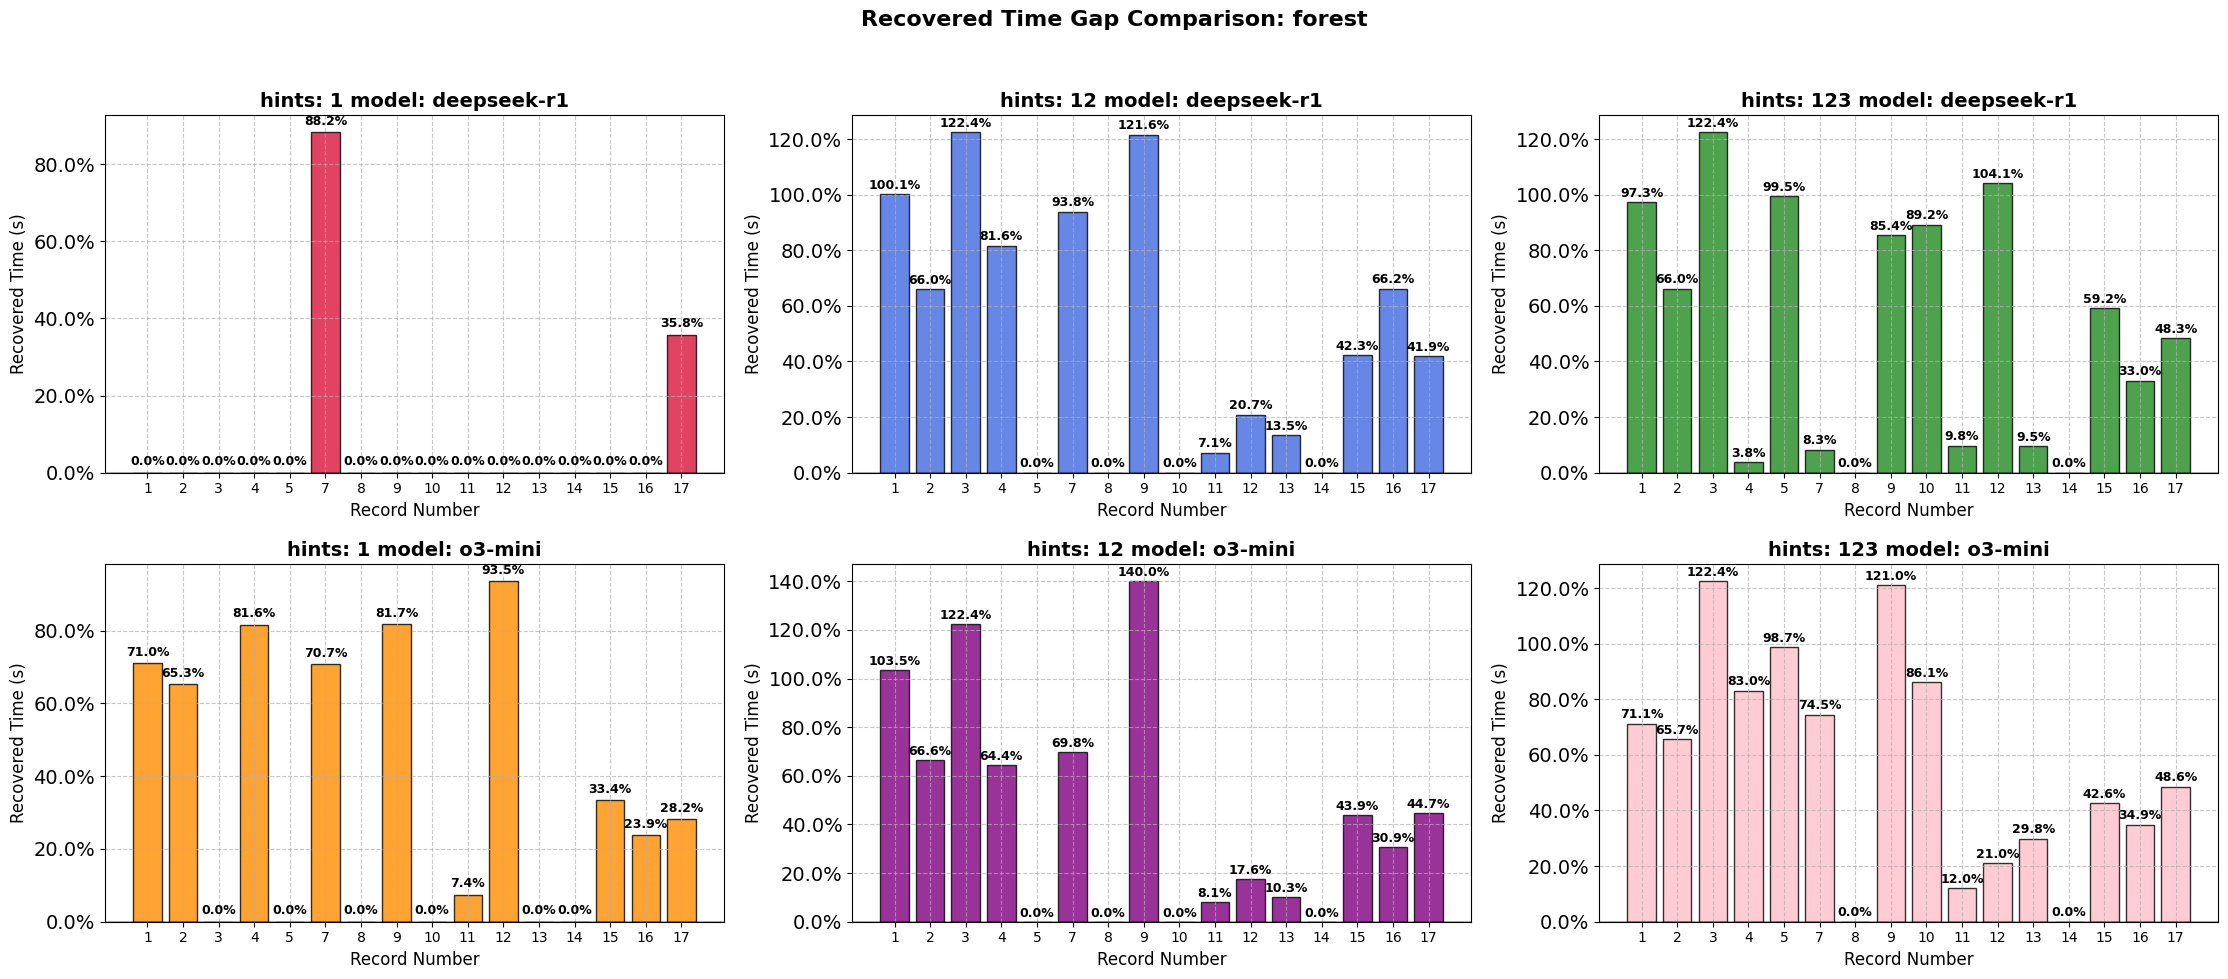

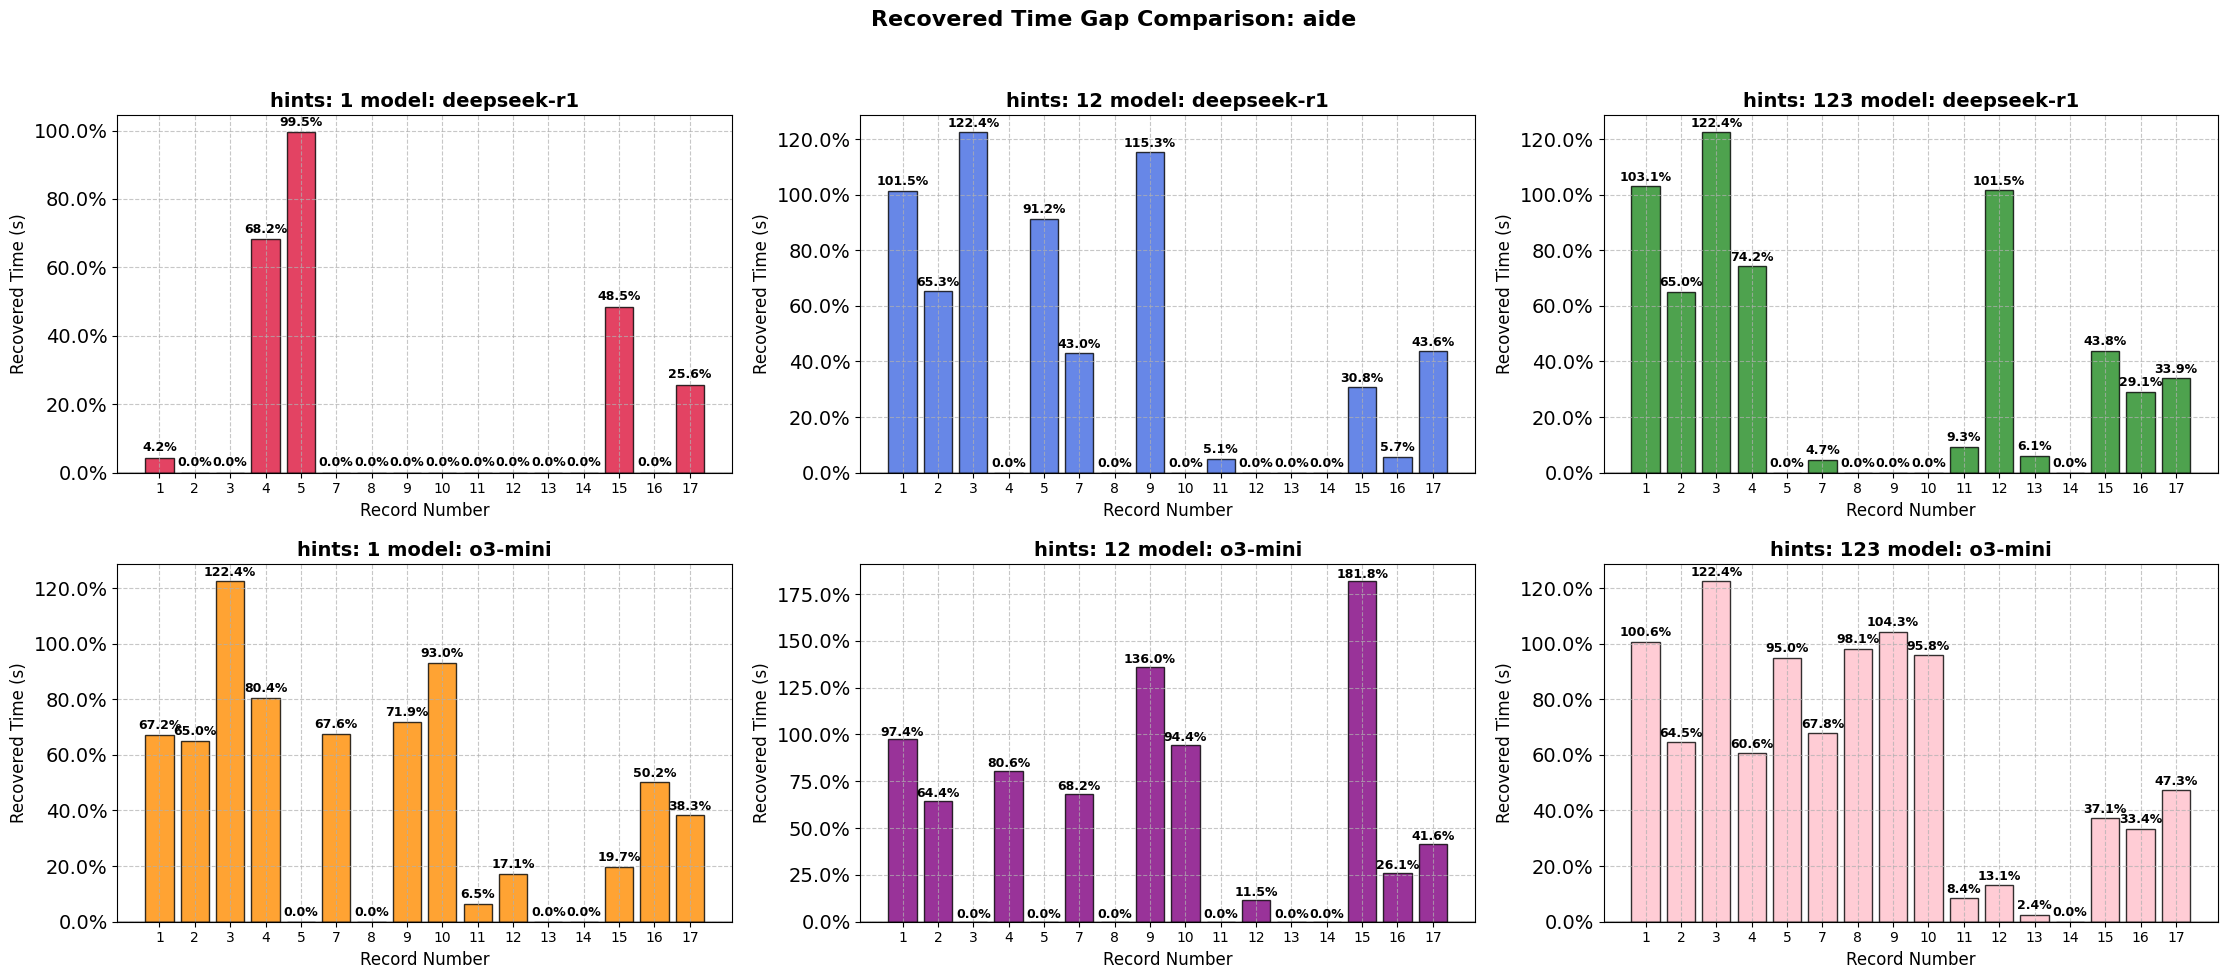

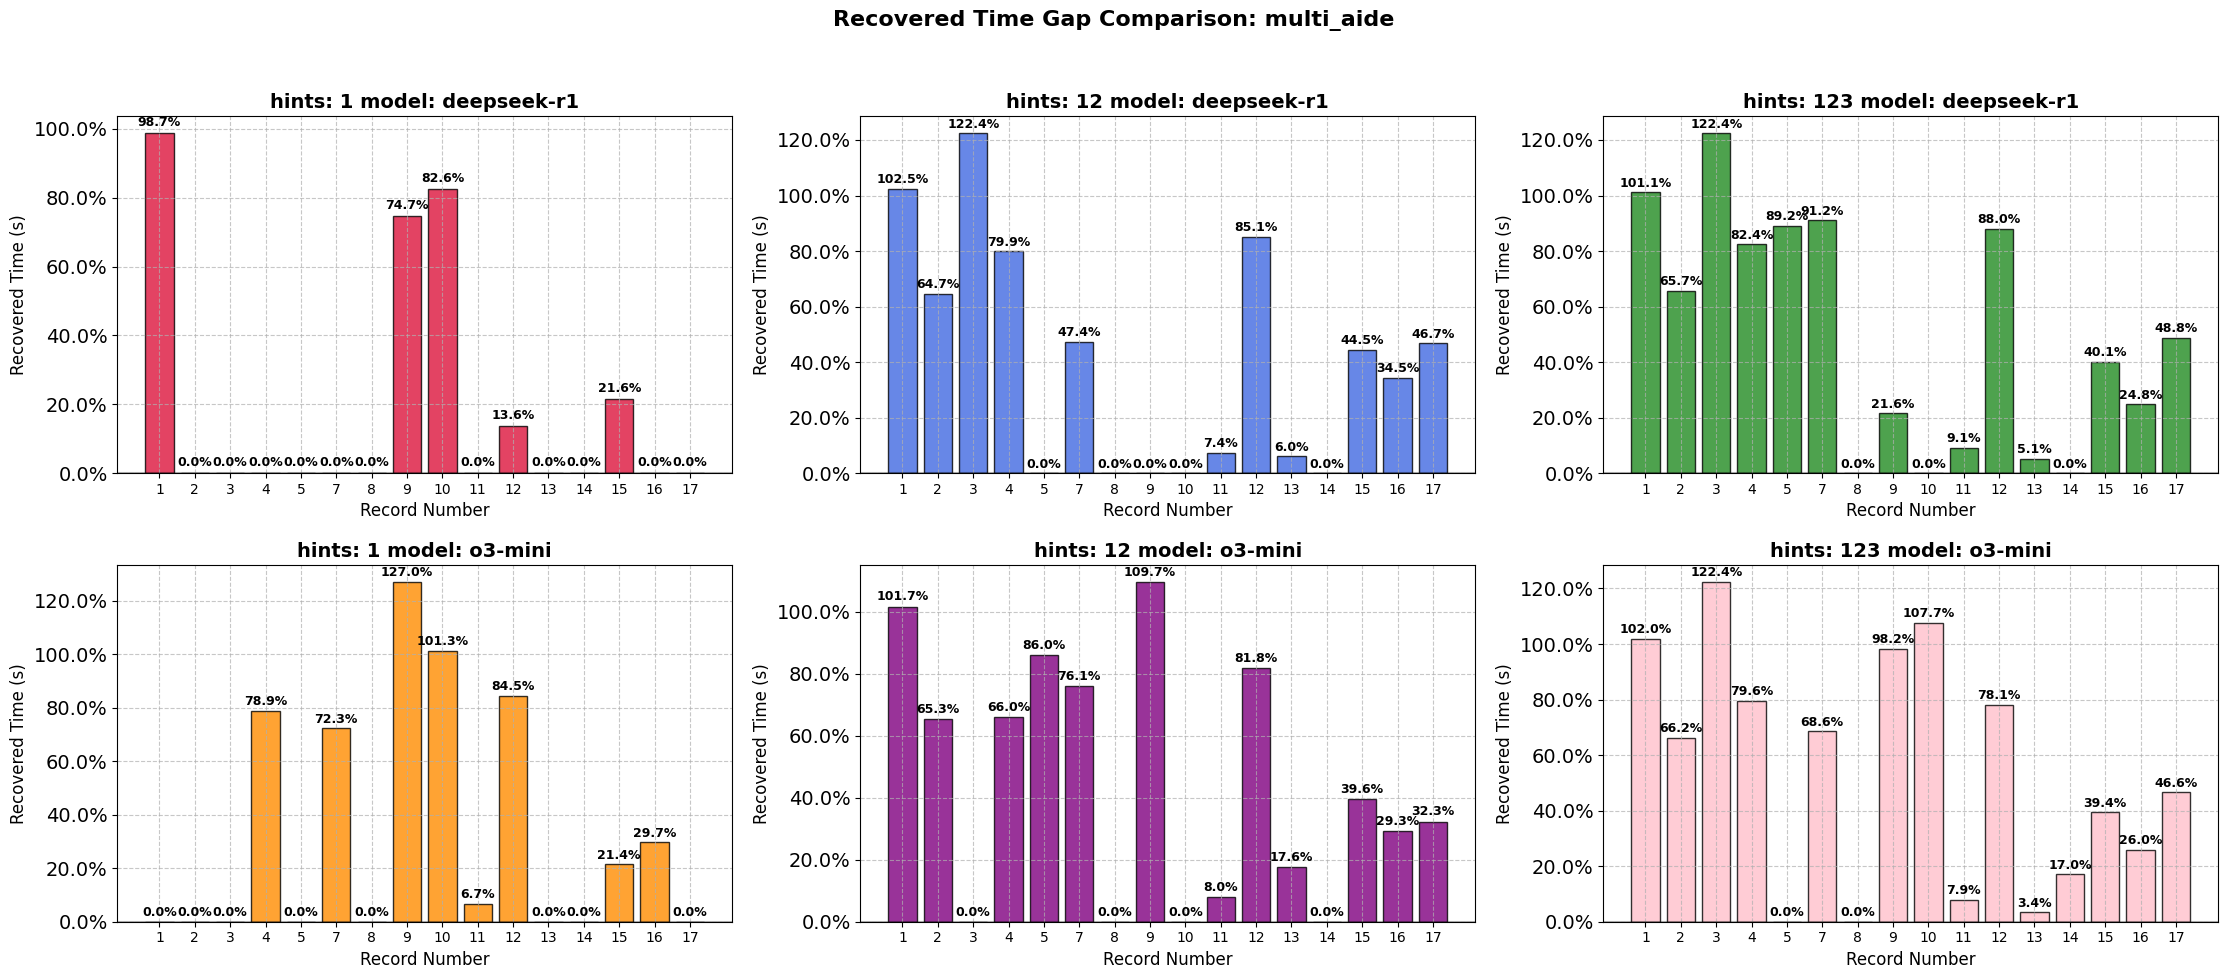

In [18]:
# get 6 colors
colors = ['crimson', 'royalblue', 'forestgreen', 'darkorange', 'purple', 'pink']
for search_algo in ['flat', 'tree', 'forest', 'aide', 'multi_aide']:
    filtered_figure_data = {k: v for k, v in figure_data.items() if search_algo in k}
    data_dicts = []
    i = 0
    for model in ('deepseek-r1', 'o3-mini'):
        for level in [1, 12, 125]:
            if level == 125:
                level_plot = 123
            else:
                level_plot = level
            data_dicts.append((
                filtered_figure_data[f'{search_algo}_{level}_{model}'], 
                f'hints: {level_plot} model: {model}', 
                colors[i]
            ))
            i += 1
    plot_gap_comparison(
        data_dicts, 
        figsize=(15, 10), 
        # n_cols=3, 
        main_title=f'Recovered Time Gap Comparison: {search_algo}'
    )
    plt.savefig(f'../figures/{search_algo}_placeholder.pdf', dpi=150)
